上游代码：`ControlPattern3D-Qualisys.py`

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import plotly.graph_objs as go
import plotly.io as pio
from mayavi import mlab
import imageio

# 在 Jupyter Notebook 中启用图表显示
pio.renderers.default = 'notebook'
mlab.init_notebook(backend='ipy', width=None, height=None, local=True)

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

Notebook initialized with ipy backend.


---
self.E, self.nu = 2.e3, 0.4; Desired pos=+[0.01, 0., -0.03]

In [5]:
num:int = 1
loss_np = np.loadtxt(f"loss_list{num}.csv", delimiter=',')
marker_pos_np = np.loadtxt(f"dot_pos_list{num}.csv", delimiter=',')
left_ur_data = pd.read_csv(f'left_robot_data{num}.csv')

column_titles = left_ur_data.columns.tolist()
print(f'Column titles: {column_titles}')

time = left_ur_data['timestamp'].to_numpy()
time -= time[0]

left_rob_x = left_ur_data['actual_TCP_pose_0'].to_numpy()
left_rob_y = left_ur_data['actual_TCP_pose_1'].to_numpy()
left_rob_z = left_ur_data['actual_TCP_pose_2'].to_numpy()
left_rob_rx = left_ur_data['actual_TCP_pose_3'].to_numpy()
left_rob_ry = left_ur_data['actual_TCP_pose_4'].to_numpy()
left_rob_rz = left_ur_data['actual_TCP_pose_5'].to_numpy()

Column titles: ['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


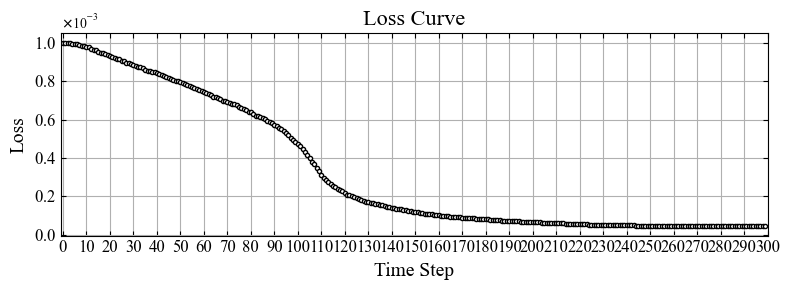

In [8]:
step_num = loss_np.shape[0]
plot_step_num = 300

# plot loss curve
fig = plt.figure(figsize=(8, 3), dpi=100)
gs = GridSpec(1, 1, figure=fig)

axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(loss_np[:plot_step_num], marker='.', markerfacecolor='white', linestyle='-', color='k', label=f'Distance Loss', zorder=3)
axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', labelsize=12, direction='in', top=True, right=True)
# fig.legend(loc='upper right', fontsize=12, bbox_to_anchor=(1, 1), bbox_transform=axs_loss.transAxes)
axs_loss.grid(True, zorder=1)

fig.tight_layout()

In [12]:
trace_marker = go.Scatter3d(x=marker_pos_np[:plot_step_num, 0], y=marker_pos_np[:plot_step_num, 1], z=marker_pos_np[:plot_step_num, 2], mode='lines', 
                            name='Trajectory', line=dict(color='black', width=4))

end_points = marker_pos_np[-1,:].reshape(-1, 3)
start_points = marker_pos_np[0,:].reshape(-1, 3)
desired_points = marker_pos_np[0,:].reshape(-1, 3) + np.array([0.01, 0, -0.03])
start_scatter = go.Scatter3d(x=start_points[:, 0], y=start_points[:, 1], z=start_points[:, 2], mode='markers', name='Start Points', marker=dict(color='red', size=5, symbol='circle'))
end_sactter = go.Scatter3d(x=end_points[:, 0], y=end_points[:, 1], z=end_points[:, 2], mode='markers', name='End Points', marker=dict(color='blue', size=5, symbol='diamond'))
desired_scatter = go.Scatter3d(x=desired_points[:, 0], y=desired_points[:, 1], z=desired_points[:, 2], mode='markers', name='Desired Points', marker=dict(color='green', size=5, symbol='cross'))

# 设置布局
layout = go.Layout(title='3D Trajectory', scene=dict(xaxis_title='X Axis', yaxis_title='Y Axis', zaxis_title='Z Axis'))

# 创建图形
fig = go.Figure(data=[trace_marker], layout=layout)
fig.add_trace(start_scatter)
fig.add_trace(end_sactter)
fig.add_trace(desired_scatter)
fig.update_layout(autosize=False, xaxis=dict(scaleanchor="y", scaleratio=1), yaxis=dict(scaleanchor="x", scaleratio=1), width=800, height=600)

# 显示图形
fig.show()